In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# Calculate potential vorticity
df_ST = calc_pv(df_ST)

In [3]:
df_ST.head()

,Conservative_Temperature_[deg_C],Absolute_Salinity_[PSU],Dissolved_Oxygen_[micro_mol_per_kg],Depth_[m],Latitude_[deg_N],Longitude_[deg_E],year,month,Profile_Number,Pv
0,9.222,35.352,NaN,15.0,63.315,-0.075,2009,8,1,1.572741e-08
1,7.958,35.402,NaN,105.0,63.317,-0.017,2009,8,1,-2.711059e-10
2,7.831,35.402,NaN,115.0,63.318,-0.090,2009,8,1,-2.050461e-10
3,7.724,35.400,NaN,125.0,63.309,-0.068,2009,8,1,-3.112159e-10
4,7.550,35.395,NaN,135.0,63.368,-0.018,2009,8,1,-3.764021e-11


In [4]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Define a list of random seeds
seeds = random.sample(range(1, 10000), 10)

In [5]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]','Pv']

In [6]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:1026: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [9]:
# Run BIC score calculation for different numbers of clusters and for 10 different seeds
# Do BIC and AIC calculation for different number of clusters
all_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds[0:2]):
    bic_scores = [] 
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_ST[features])
        bic_scores.append(gmm.bic(df_ST[features]))

    all_scores[i] = bic_scores

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components (seed 0)')

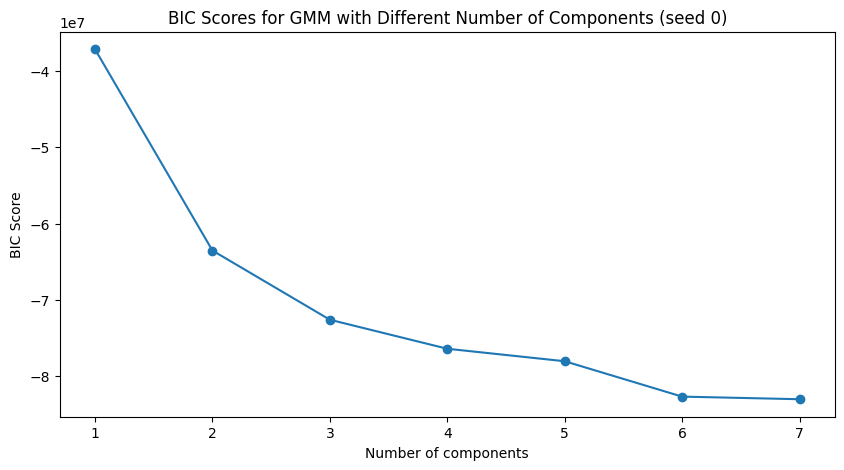

In [10]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, all_scores[0], label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components (seed 0)')

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components (seed 1)')

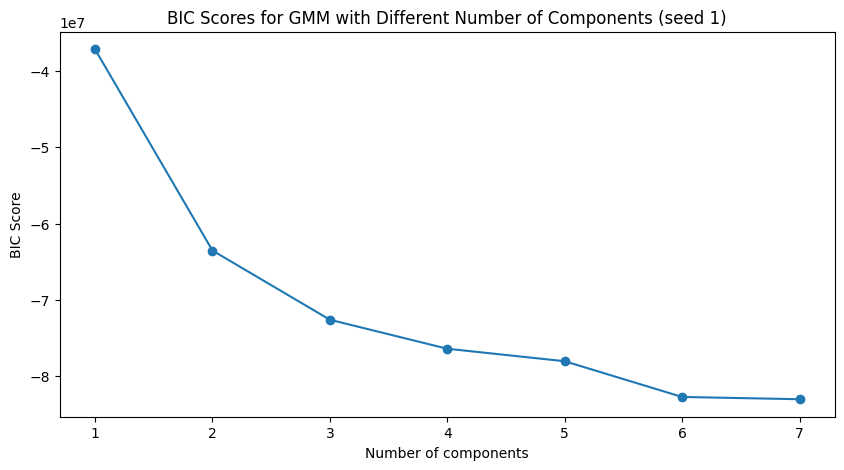

In [11]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, all_scores[1], label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components (seed 1)')

In [12]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [24]:
gmm_0 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels_0 = gmm_0.fit_predict(df_sampled[features])

In [25]:
gmm_1 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[1])

labels_1 = gmm_1.fit_predict(df_sampled[features])

In [32]:
df_sampled['gmm_label_6'] = labels_0
df_sampled['gmm_label_6'] = labels_1

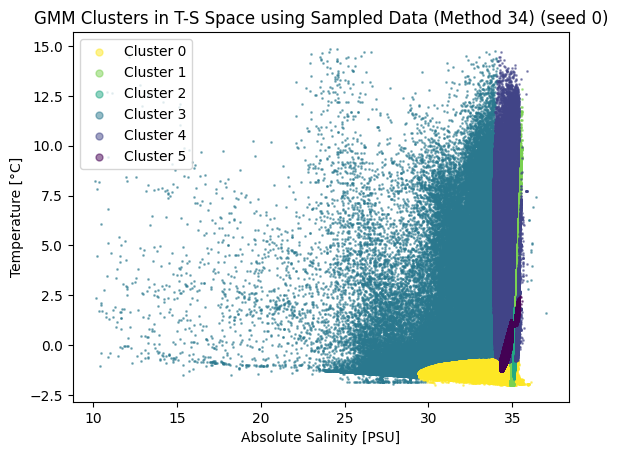

In [30]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



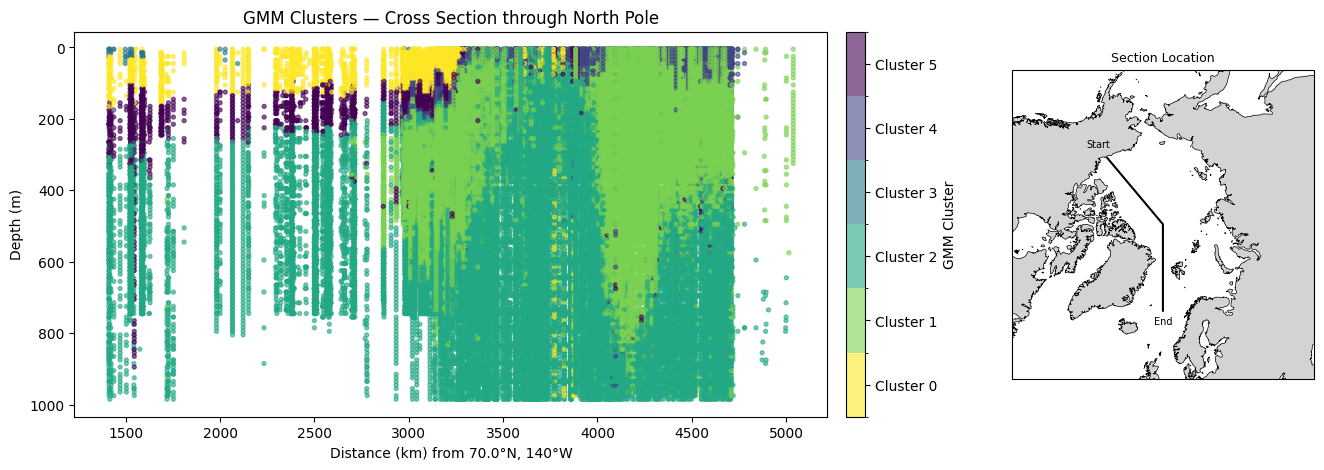

In [31]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

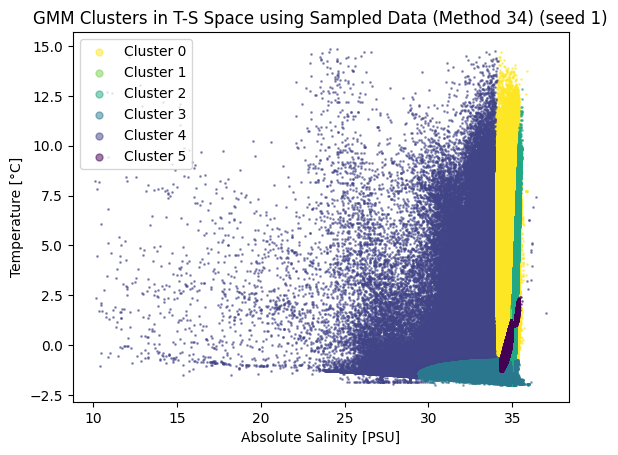

In [33]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 1)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



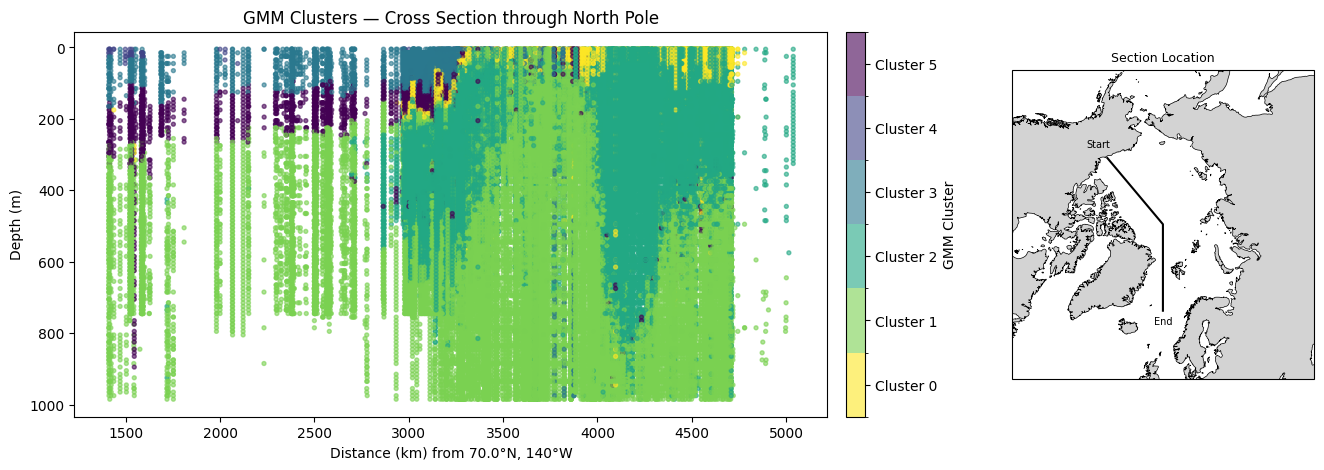

In [34]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [35]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_0.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



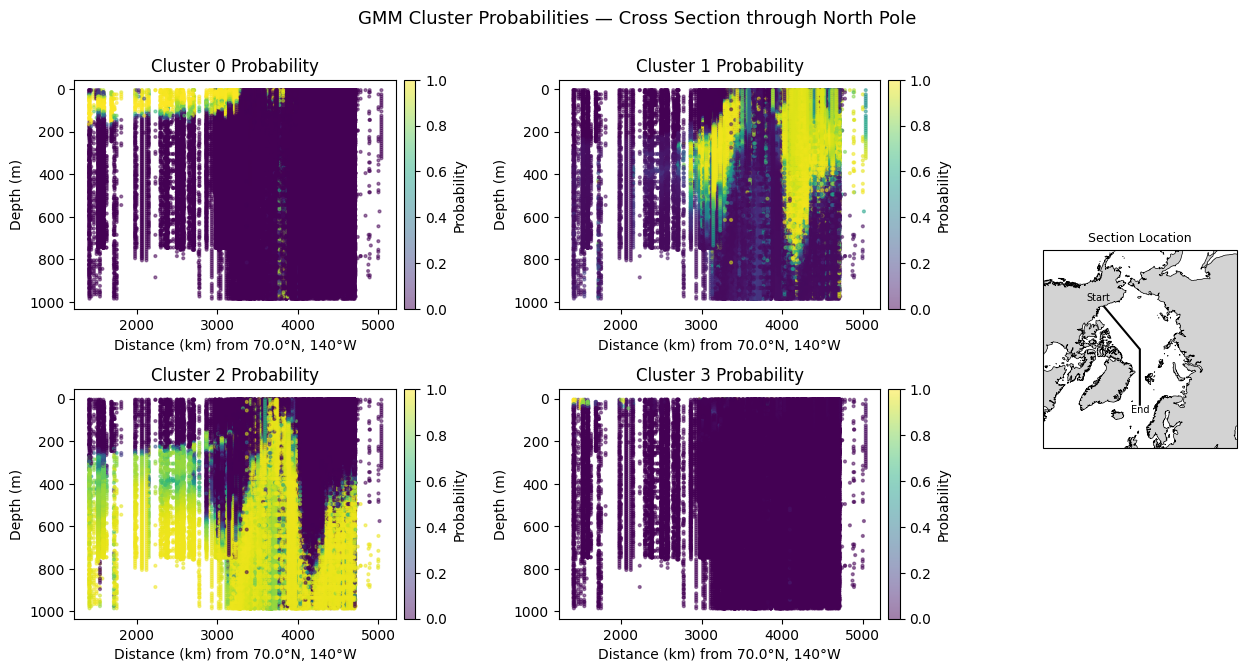

In [36]:
cross_sec_lon_prob(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:928: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



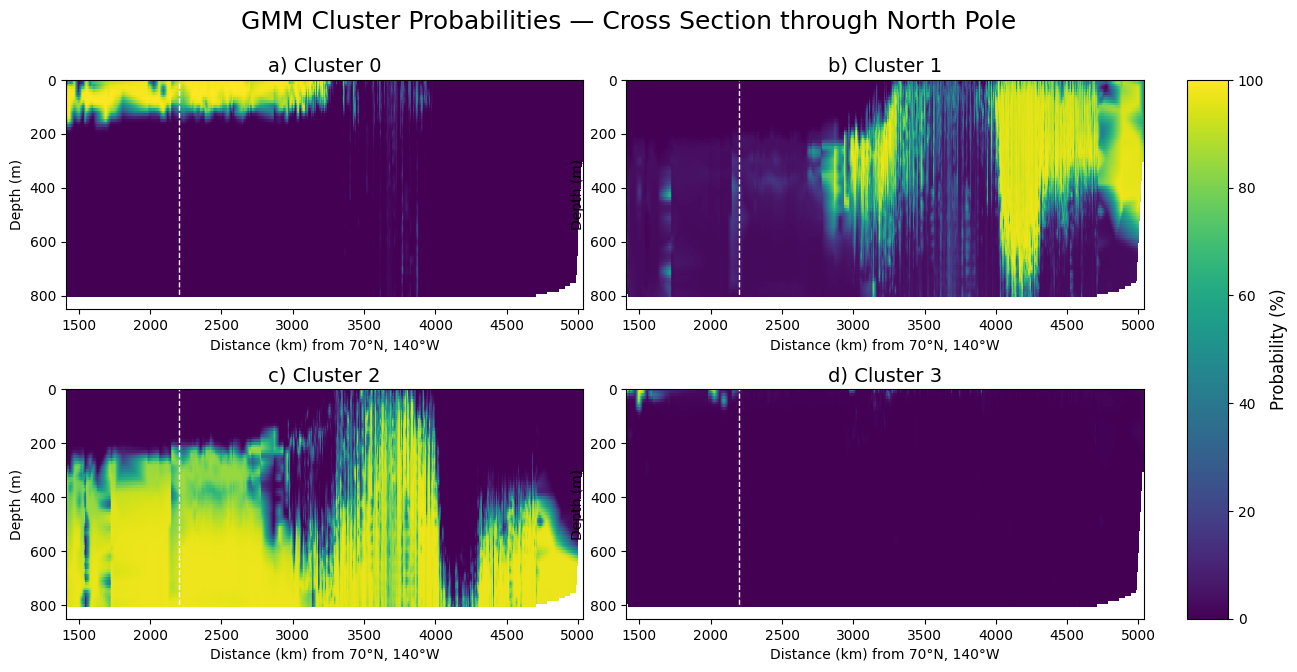

In [37]:
cross_sec_lon_prob2(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [38]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_1.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



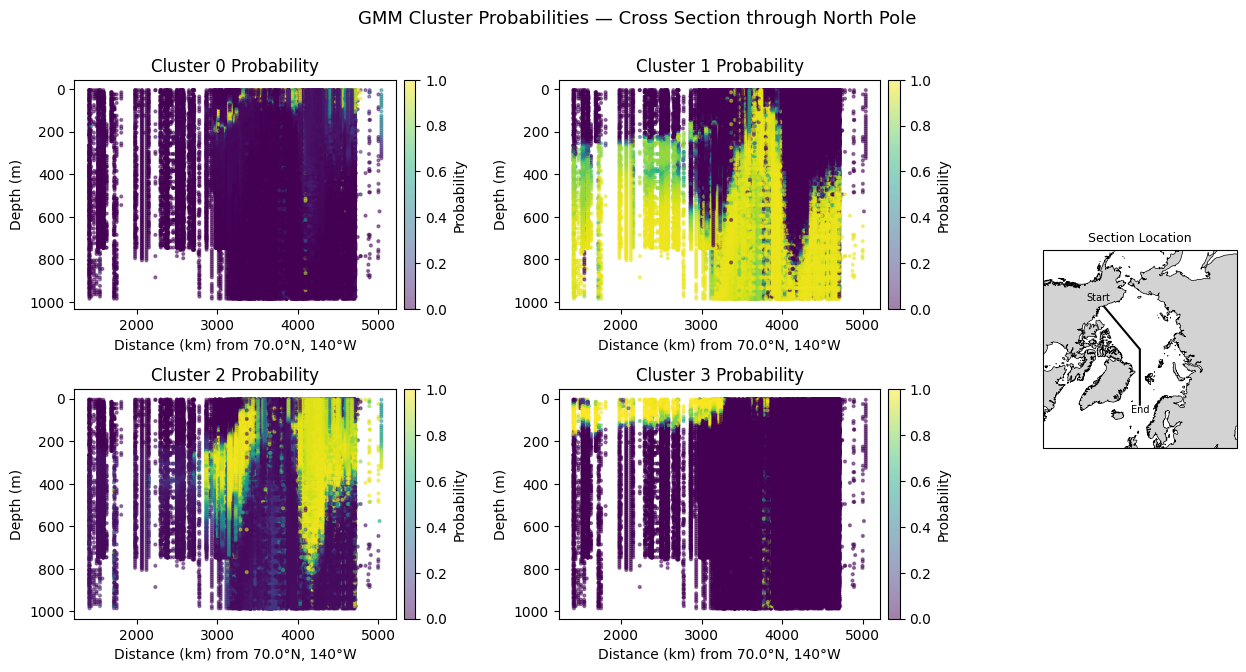

In [39]:
cross_sec_lon_prob(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:928: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



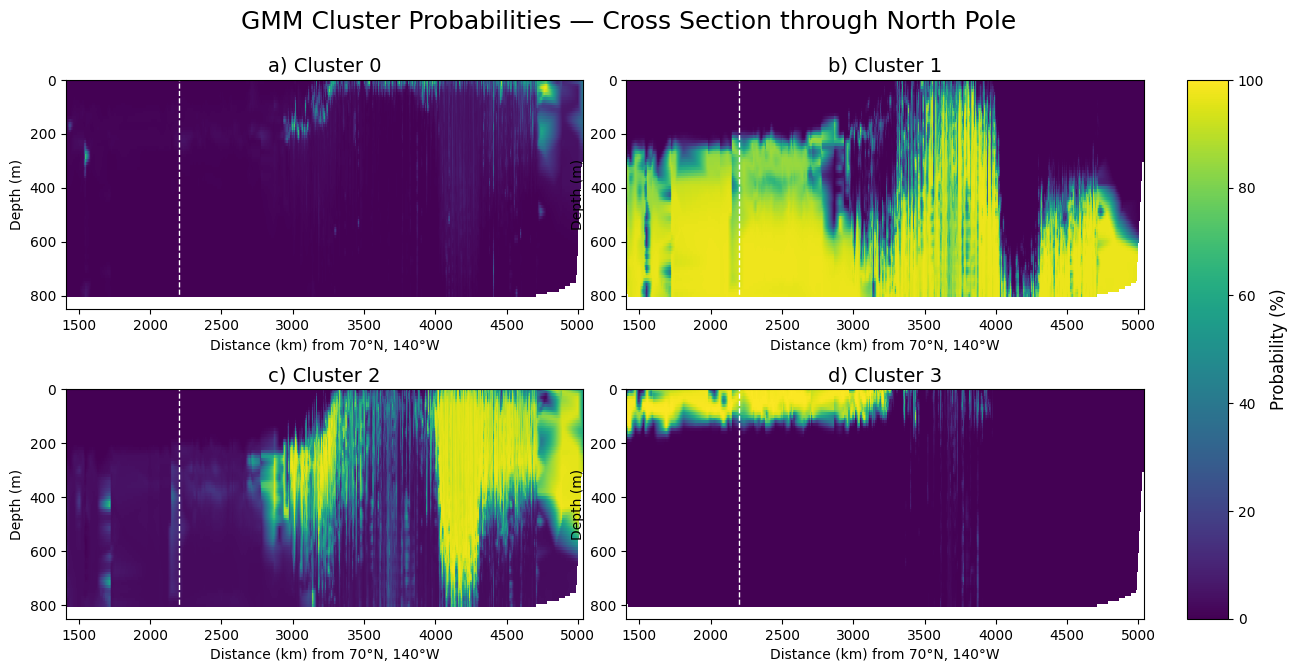

In [40]:
cross_sec_lon_prob2(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)